# Example frame

Load `data/example_frame.png` with OpenCV and show it in the notebook (BGR → RGB for correct colors).

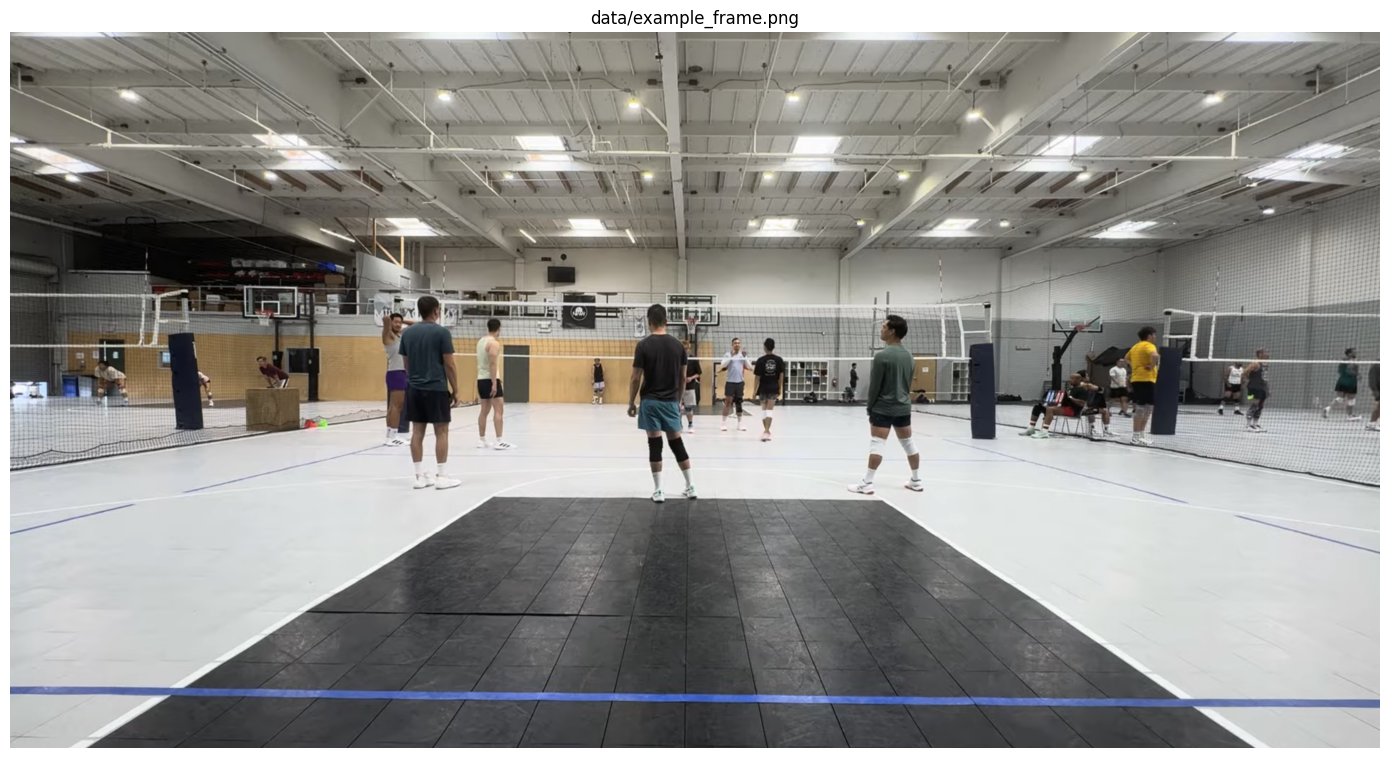

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

# Repo root = parent of notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

image_path = ROOT / "data" / "example_frame.png"
bgr = cv2.imread(str(image_path))

if bgr is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(rgb)
plt.axis("off")
plt.title(str(image_path.relative_to(ROOT)))
plt.tight_layout()
plt.show()

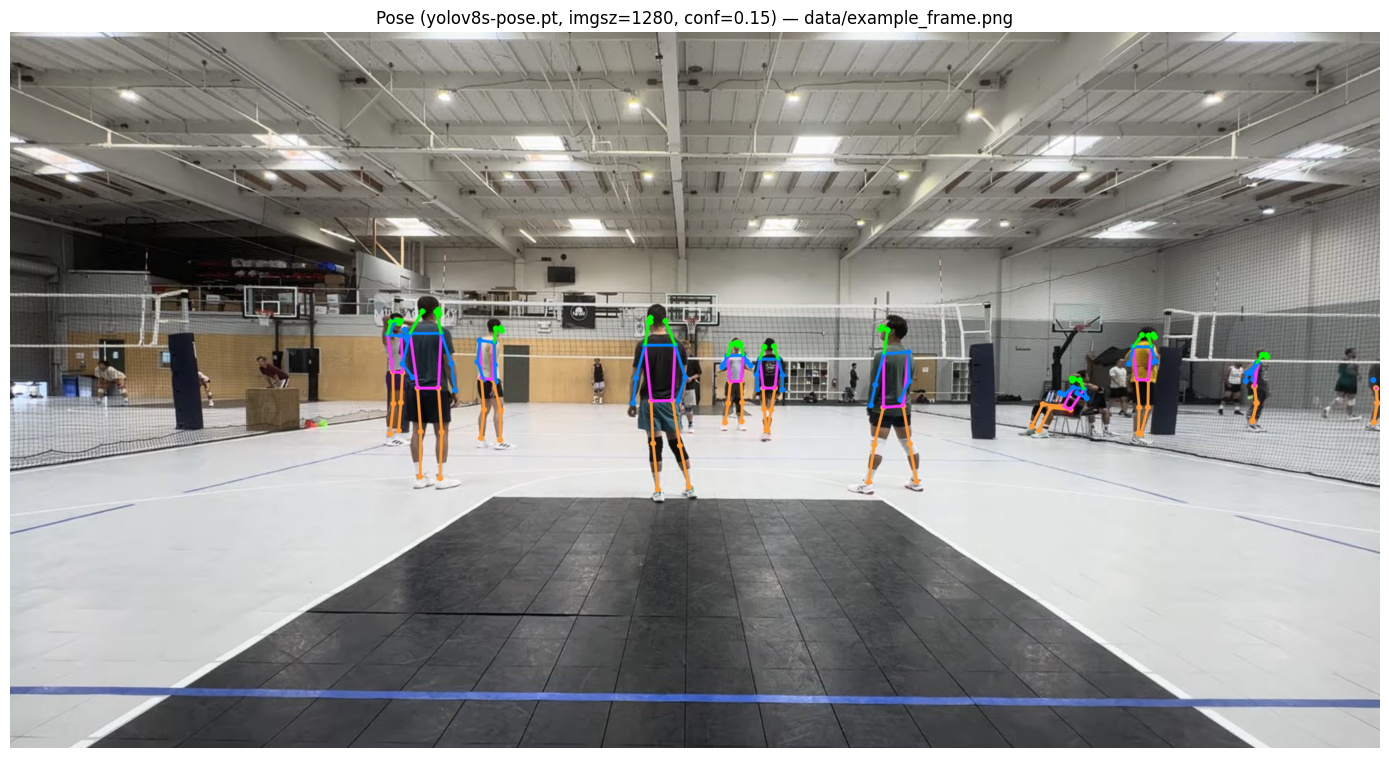

In [5]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Repo root = parent of notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

image_path = ROOT / "data" / "example_frame.png"
# Pretrained COCO-pose (downloads on first use). See:
# https://docs.ultralytics.com/tasks/pose/#models
# `s` trades speed for better small / distant figures vs `n`; switch to yolov8n-pose.pt if needed.
POSE_WEIGHTS = "yolov8s-pose.pt"
IMGSZ = 1280  # larger than default 640 helps small people in wide shots
CONF = 0.15  # below default 0.25 to keep weaker small-person detections
MAX_DET = 300

model = YOLO(POSE_WEIGHTS)

results = model(
    str(image_path),
    imgsz=IMGSZ,
    conf=CONF,
    max_det=MAX_DET,
    verbose=False,
)
result = results[0]

# BGR: keypoints + skeleton only (no boxes / class / confidence text)
annotated_bgr = result.plot(boxes=False, labels=False, conf=False)
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title(
    f"Pose ({POSE_WEIGHTS}, imgsz={IMGSZ}, conf={CONF}) — "
    + str(image_path.relative_to(ROOT))
)
plt.tight_layout()
plt.show()

In [2]:
import json
from pathlib import Path

import cv2
import numpy as np

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

with open(DATA / "project-1-at-2026-04-28-04-06-975ac587.json") as f:
    tasks = json.load(f)

video_path = str(DATA / "example_video.mp4")
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

task = tasks[0]

# 0 = unlabeled, 1 = Downtime, 2 = Playing
labels = np.zeros(total_frames, dtype=np.uint8)
label_map = {"Downtime": 1, "Playing": 2}

for region in task["videoLabels"]:
    label_name = region["timelinelabels"][0]
    label_id = label_map[label_name]
    for r in region["ranges"]:
        start, end = int(r["start"]), int(r["end"])
        labels[start:end + 1] = label_id

# Quick sanity stats
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    name = {0: "unlabeled", 1: "Downtime", 2: "Playing"}[u]
    print(f"{name}: {c} frames ({c/30:.2f}s)")

unlabeled: 2383 frames (79.43s)
Downtime: 1002 frames (33.40s)
Playing: 440 frames (14.67s)
